# Explore the released experiment data

## Goal

Interpret the data quality and randomization checks produced by `scripts/prepare_data.py`. The pipeline creates the tables; this notebook is a reader-facing walkthrough.

## Setup

The public Criteo benchmark is anonymized and non-uniformly subsampled. Each row is treated as one released experimental record. Identical rows are retained because no user or event identifier is available to establish that they are accidental duplicates.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
TABLES = PROJECT_ROOT / "results" / "tables"
FIGURES = PROJECT_ROOT / "results" / "figures"

## Checks

In [2]:
quality = pd.read_csv(TABLES / "eda/quality_checks.csv")
allocation = pd.read_csv(TABLES / "eda/arm_summary.csv")
duplicates = pd.read_csv(TABLES / "eda/duplicate_summary.csv")
display(quality, allocation, duplicates)

,rows,missing_rows,invalid_binary_rows,nonfinite_feature_rows,conversion_without_visit,exposed_controls
0,13979592,0.0,0.0,0.0,0.0,0.0


,treatment,rows,visit_positive,conversion_positive,exposed
0,0,2096937,80105.0,4063.0,0.0
1,1,11882655,576824.0,36711.0,428212.0


,groups,rows_in_groups,extra_identical_records
0,961605,2221150.0,1259545.0


The pipeline requires the expected 13,979,592 rows, complete finite features, valid binary fields, no exposed controls, and no conversions without visits. Duplicate-looking records remain part of the released experiment.

,feature,control_mean,treatment_mean,smd,absolute_smd
3,f3,4.232821,4.169412,-0.048836,0.048836
6,f6,-3.999880,-4.182792,-0.040448,0.040448
5,f5,4.039339,4.026602,-0.030557,0.030557
9,f9,15.886253,16.052589,0.024001,0.024001
1,f1,10.067935,10.070337,0.023994,0.023994
8,f8,3.934652,3.933392,-0.022433,0.022433
7,f7,5.080284,5.105555,0.021270,0.021270
10,f10,5.331898,5.333660,0.010563,0.010563
4,f4,10.336526,10.339245,0.007966,0.007966
0,f0,19.651705,19.614755,-0.006866,0.006866


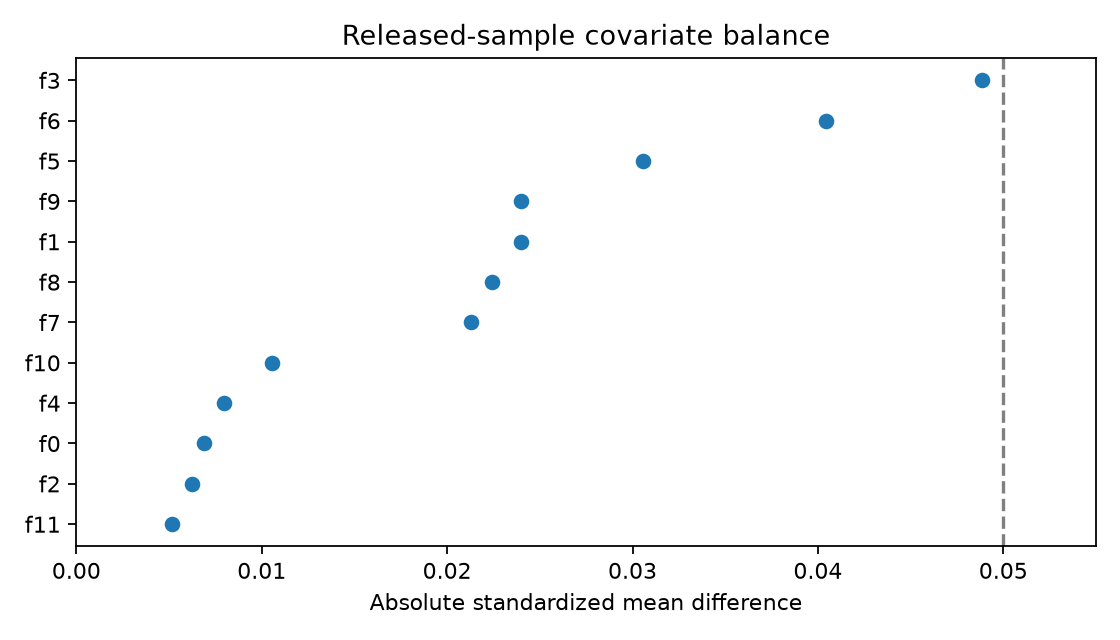

In [3]:
balance = pd.read_csv(TABLES / "eda/feature_balance.csv")
display(balance.sort_values("absolute_smd", ascending=False))
display(Image(filename=FIGURES / "eda/feature_balance.png"))

All absolute standardized mean differences are assessed against the project diagnostic threshold of 0.05. This supports observable released-sample balance; it cannot test hidden variables or reconstruct the original advertiser population.

## Next steps
Run `scripts/estimate_incrementality.py`, then use the incrementality notebook.